In [1]:
title = "# Random variables and probability distributions: Exercises"
# Print title and setup TeX defs for both KaTeX and MathJax
import bayesian_stats_course_tools
bayesian_stats_course_tools.misc.display_markdown_and_setup_tex(title)

import matplotlib.style
matplotlib.style.use("bayesian_stats_course_tools.light")

# Random variables and probability distributions: Exercises

<!-- Define LaTeX macros -->
$\def\E{\operatorname{E}}$
$\def\Var{\operatorname{Var}}$
$\def\Cov{\operatorname{Cov}}$
$\def\dd{\mathrm{d}}$
$\def\ee{\mathrm{e}}$
$\def\Norm{\mathcal{N}}$
$\def\Uniform{\mathcal{U}}$
$\def\GP{\mathcal{GP}}$

<!-- MathJax needs them to be defined again for the non-inline environment -->
$$\def\E{\operatorname{E}}$$
$$\def\Var{\operatorname{Var}}$$
$$\def\Cov{\operatorname{Cov}}$$
$$\def\dd{\mathrm{d}}$$
$$\def\ee{\mathrm{e}}$$
$$\def\Norm{\mathcal{N}}$$
$$\def\Uniform{\mathcal{U}}$$
$$\def\GP{\mathcal{GP}}$$

### Exercise 1

Consider the distribution with PDF

$$
p(x) =
\begin{cases}
\frac{1}{2}\sin x, & 0 \leq x \leq \pi, \\
0, & \text{otherwise}.
\end{cases}
$$

1. Derive the CDF
   $$
   F(x) = \int_{-\infty}^{x} p(x')\, dx'
   $$
   analytically, and plot it together with the PDF $p(x)$.

2. Find the inverse CDF $F^{-1}(u)$, and use it to transform samples
   $$
   U \sim \mathrm{Uniform}(0,1)
   $$
   into samples $X = F^{-1}(U)$ (inverse transform sampling).

3. Compare a density-normalised histogram of the samples with the PDF $p(x)$.

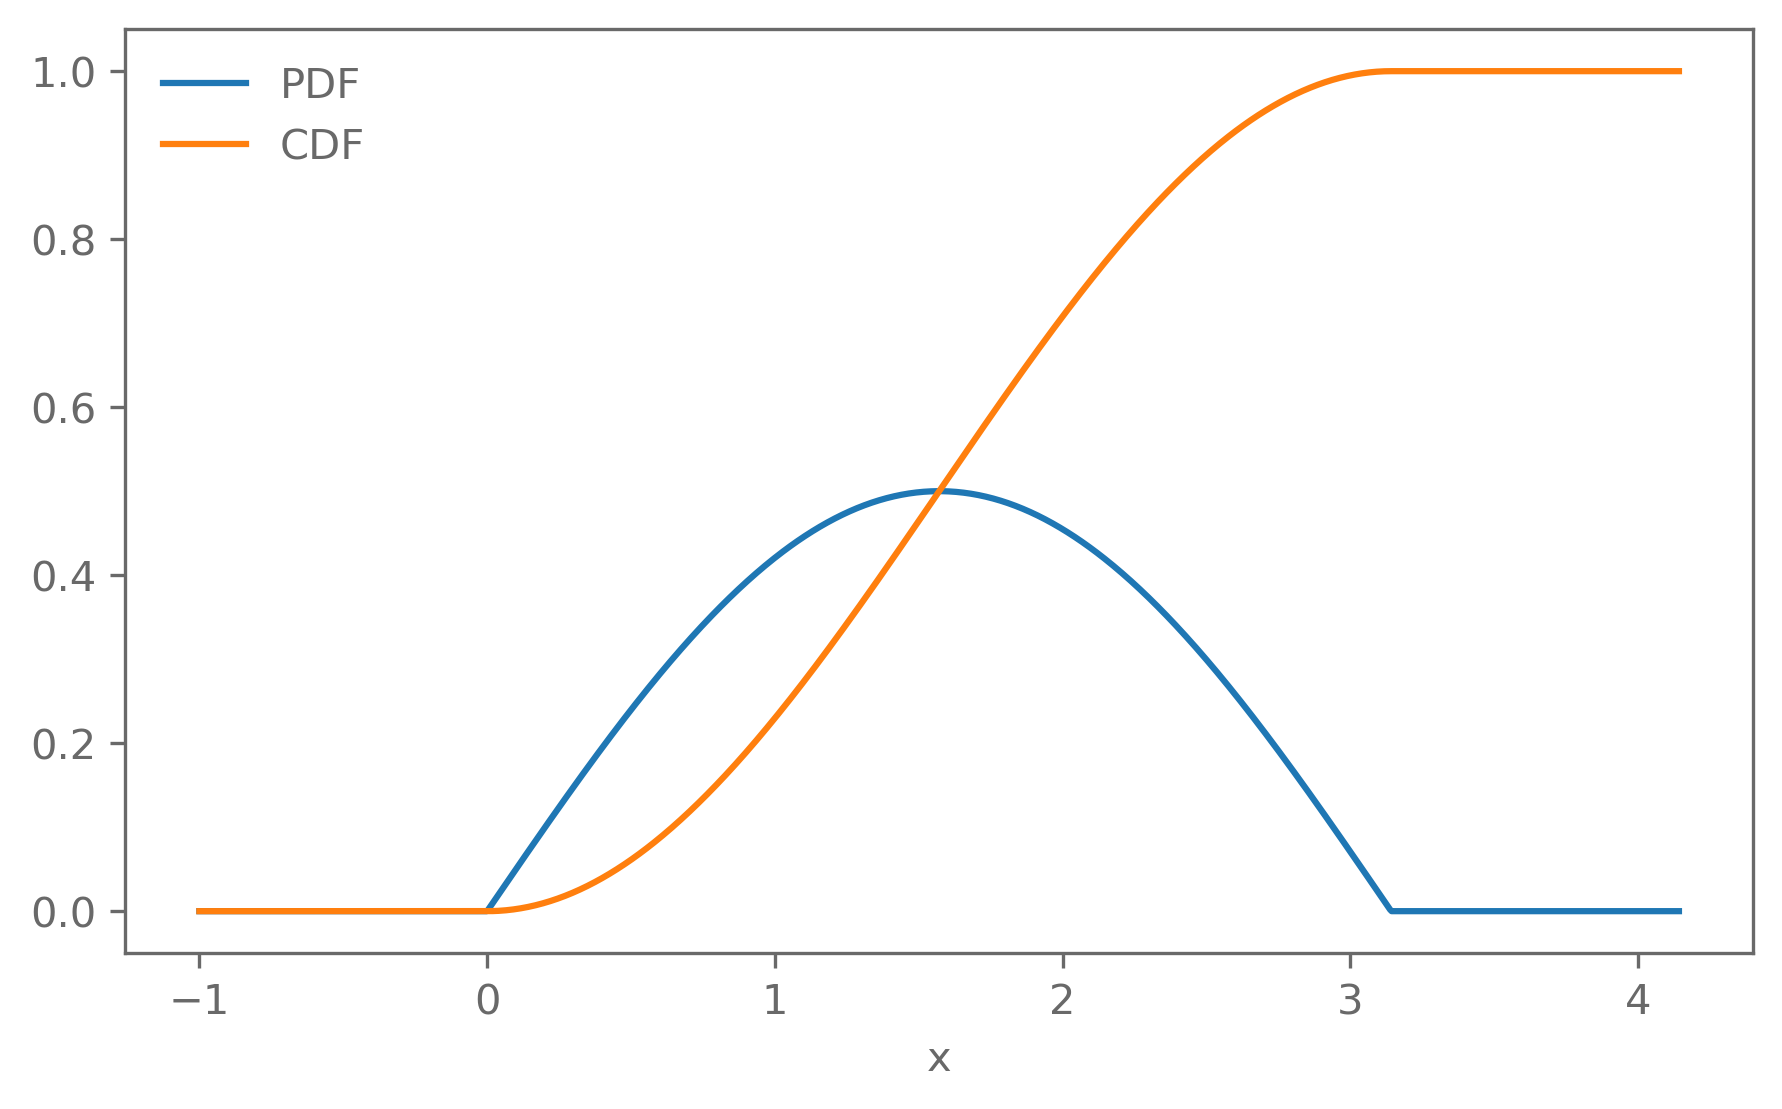

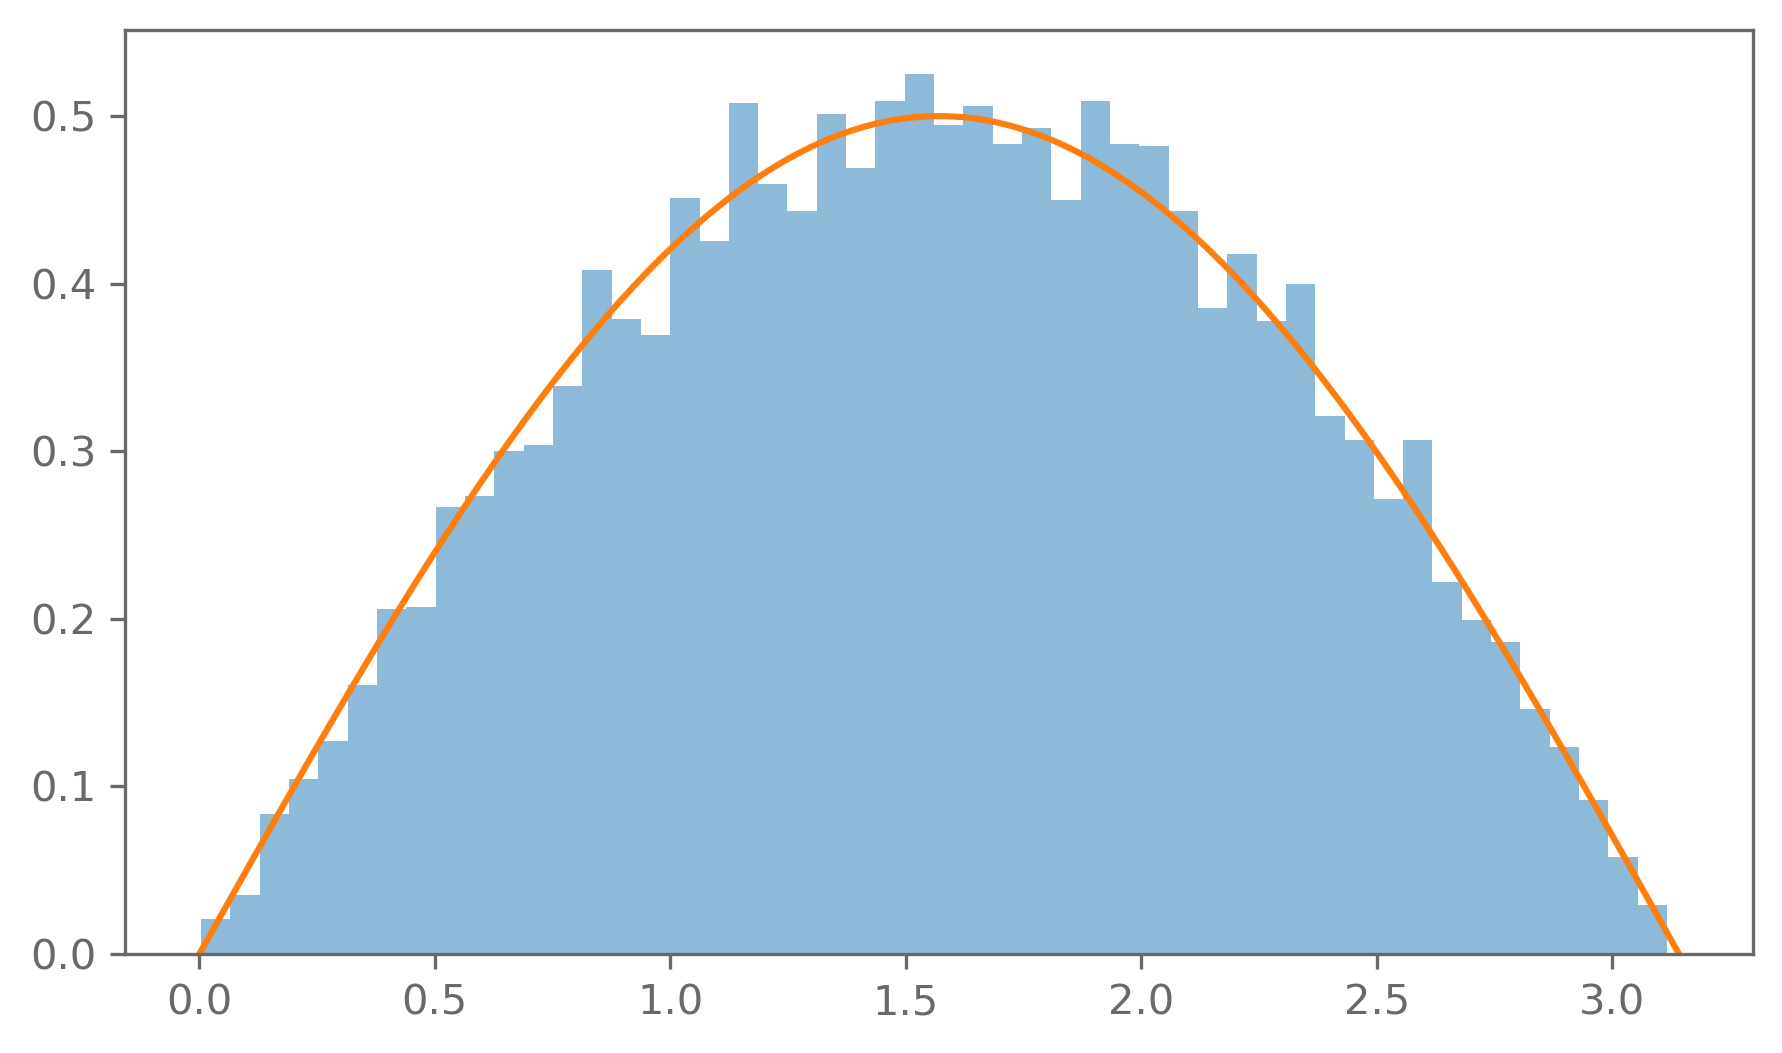

In [6]:
import numpy as np
import matplotlib.pyplot as plt

## 1.
# Grid
x = np.linspace(-1, np.pi + 1, 1000)

# PDF
pdf = np.where(
    (x >= 0) & (x <= np.pi),
    0.5 * np.sin(x),
    0
)

# CDF
cdf = np.piecewise(
    x,
    [x < 0, (x >= 0) & (x <= np.pi), x > np.pi],
    [
        0,
        lambda x: 0.5 * (1 - np.cos(x)),
        1
    ]
)

# Plot PDF and CDF
plt.plot(x, pdf, label="PDF")
plt.plot(x, cdf, label="CDF")
plt.xlabel("x")
plt.legend()
plt.show()


## 2
N = 10000

u = np.random.uniform(0, 1, N)
x_samples = np.arccos(1 - 2*u)

x_plot = np.linspace(0, np.pi, 500)
pdf_plot = 0.5 * np.sin(x_plot)

plt.hist(x_samples, bins=50, density=True, alpha=0.5)
plt.plot(x_plot, pdf_plot)
plt.show()

### Exercise 2

Consider a random variable with distribution $p(x)$, mean
$\mathbb{E}[x] = \mu$ and variance
$\mathrm{Var}[x] = \sigma^2$, and let $a$ and $c$ be constants.

Using the definition of the expectation,

$$
\mathbb{E}[f(x)]
=
\int_{-\infty}^{\infty} f(x)\,p(x)\,\mathrm{d}x,
$$

show that:

**Mean**

1. $\mathbb{E}[x+a] = \mu+a$
2. $\mathbb{E}[cx] = c\mu$

**Variance**

3. $\mathrm{Var}[x]
   = \mathbb{E}[(x-\mathbb{E}[x])^2]
   = \mathbb{E}[x^2]-\mathbb{E}[x]^2$
4. $\mathrm{Var}[x+a] = \sigma^2$
5. $\mathrm{Var}[cx] = c^2\sigma^2$

*Hint:* use the linearity of the expectation (results 1 and 2) to prove results 3–5.

### Exercise 3

Let $X_1, \dots, X_n$ be $n$ i.i.d. random variables with
$X_i \sim \mathrm{Uniform}(0,1)$, and let $K$ be the number of them
that fall into a small interval of width $\Delta x$.

1. Confirm by simulation that, for large $n$ and small $\Delta x$
   with the rate $\lambda = n\,\Delta x$ held fixed, $K$ follows a
   Poisson distribution:

$$
\Pr(K=k)
=
\frac{\lambda^k}{k!} e^{-\lambda}.
$$

2. Derive the Poisson distribution from the binomial distribution,

$$
\Pr(K=k)
=
\binom{n}{k}p^k(1-p)^{n-k},
$$

in the limit $n \to \infty$ with $np=\lambda$ held fixed.

In [10]:
n = 1000
dx = 0.005

lam = n * dx
print(lam)

x = np.random.uniform(0, 1, n)
print(x < dx)

5.0
[False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False  True False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False Fals

### Exercise 4

1. Make plots of the PDFs of the distributions covered in the lecture, varying their parameters (e.g., vary one parameter at a time while keeping the others fixed: for the normal distribution, plot $\mathcal{N}(\mu, 1)$ for three values of $\mu$, and $\mathcal{N}(0, \sigma^2)$ for three values of $\sigma^2$). For discrete distributions, such as the binomial and Poisson, plot the PMF instead.

2. Compute the distribution of the sum $Z = X + Y$ of two independent Gaussian RVs
   $X \sim \mathcal{N}(\mu_X, \sigma_X^2)$ and
   $Y \sim \mathcal{N}(\mu_Y, \sigma_Y^2)$.

   *Hint:* the lecture states that sums of Gaussian RVs are Gaussian, and a Gaussian is completely determined by its mean and variance, so it is enough to compute $\mathbb{E}[Z]$ and $\mathrm{Var}[Z]$. Independence means that the joint PDF factorises,

   $$
   p_{XY}(x,y) = p_X(x)\,p_Y(y).
   $$

3. What is the distribution of the sum $Z = X + Y$ of two independent RVs $X \sim p_X$ and $Y \sim p_Y$?

4. Derive the PDF of the $\chi^2_{\nu=1}$ distribution, i.e., of
   $Z = X^2$ with $X \sim \mathcal{N}(0,1)$.

**Bonus**

5. What is the distribution of the product $Z = UV$ of two independent RVs $U$ and $V$?

6. Compute the distribution of the ratio of two independent Gaussian RVs.